# Check rotation invariance for exp_022 composite kernel

This notebook loads `exp_022_mmr_nperFamily500_nComposition1250` and checks whether its composite kernel is rotation invariant.

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

EXP_DIR = Path('results/exp_022_mmr_nperFamily500_nComposition1250')
KERNEL_PATH = EXP_DIR / 'composite_kernel.npy'
RESULTS_PATH = EXP_DIR / 'results.json'

assert EXP_DIR.exists(), f'Missing experiment directory: {EXP_DIR}'
assert KERNEL_PATH.exists(), f'Missing kernel file: {KERNEL_PATH}'

kernel = np.load(KERNEL_PATH).astype(np.float64)
print(f'Loaded kernel from: {KERNEL_PATH}')
print(f'shape={kernel.shape}, dtype={kernel.dtype}, min={kernel.min():.6g}, max={kernel.max():.6g}')
print(f'mean={kernel.mean():.6g}, L1={np.abs(kernel).sum():.6g}, L2={np.linalg.norm(kernel):.6g}')

if RESULTS_PATH.exists():
    with open(RESULTS_PATH, 'r') as f:
        res = json.load(f)
    print(f"selected kernels in model: {len(res.get('selected_idxs', []))}")
else:
    print('results.json not found; proceeding with kernel-only check.')


Loaded kernel from: results/exp_022_mmr_nperFamily500_nComposition1250/composite_kernel.npy
shape=(31, 31), dtype=float64, min=-0.00507883, max=0.00440409
mean=-2.21719e-12, L1=1, L2=0.0420872
selected kernels in model: 90


In [2]:
def rel_l2(a, b):
    denom = np.linalg.norm(a) + 1e-12
    return np.linalg.norm(a - b) / denom

# Exact lattice-preserving rotations
exact_angles = [90, 180, 270]
exact_metrics = []
for ang in exact_angles:
    kr = np.rot90(kernel, k=ang // 90)
    exact_metrics.append({
        'angle': ang,
        'rel_l2': float(rel_l2(kernel, kr)),
        'max_abs': float(np.max(np.abs(kernel - kr))),
    })

# Interpolated rotations (if SciPy is available)
interp_metrics = []
try:
    from scipy.ndimage import rotate
    interp_angles = [15, 30, 45, 60, 75]
    for ang in interp_angles:
        kr = rotate(kernel, angle=ang, reshape=False, order=3, mode='constant', cval=0.0)
        interp_metrics.append({
            'angle': ang,
            'rel_l2': float(rel_l2(kernel, kr)),
            'max_abs': float(np.max(np.abs(kernel - kr))),
        })
    has_scipy = True
except Exception as e:
    has_scipy = False
    print(f'SciPy not available ({e}); skipping interpolated-angle checks.')

print('\nExact rotation checks (np.rot90):')
for row in exact_metrics:
    print(f"  {row['angle']:>3} deg | rel_l2={row['rel_l2']:.6e} | max_abs={row['max_abs']:.6e}")

if has_scipy:
    print('\nInterpolated rotation checks (scipy.ndimage.rotate):')
    for row in interp_metrics:
        print(f"  {row['angle']:>3} deg | rel_l2={row['rel_l2']:.6e} | max_abs={row['max_abs']:.6e}")

tol_exact = 1e-6
is_exact_invariant = max(m['rel_l2'] for m in exact_metrics) < tol_exact
print('\nVerdict (exact 90°/180°/270° invariance):', 'INVARIANT' if is_exact_invariant else 'NOT invariant')



Exact rotation checks (np.rot90):
   90 deg | rel_l2=1.405553e+00 | max_abs=7.683591e-03
  180 deg | rel_l2=1.494338e+00 | max_abs=5.832772e-03
  270 deg | rel_l2=1.405553e+00 | max_abs=7.683591e-03

Interpolated rotation checks (scipy.ndimage.rotate):
   15 deg | rel_l2=1.261725e+00 | max_abs=7.264817e-03
   30 deg | rel_l2=1.262927e+00 | max_abs=7.134991e-03
   45 deg | rel_l2=1.268373e+00 | max_abs=7.490914e-03
   60 deg | rel_l2=1.262655e+00 | max_abs=8.849520e-03
   75 deg | rel_l2=1.251213e+00 | max_abs=7.747315e-03

Verdict (exact 90°/180°/270° invariance): NOT invariant


/tmp/ipykernel_3765977/104961660.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


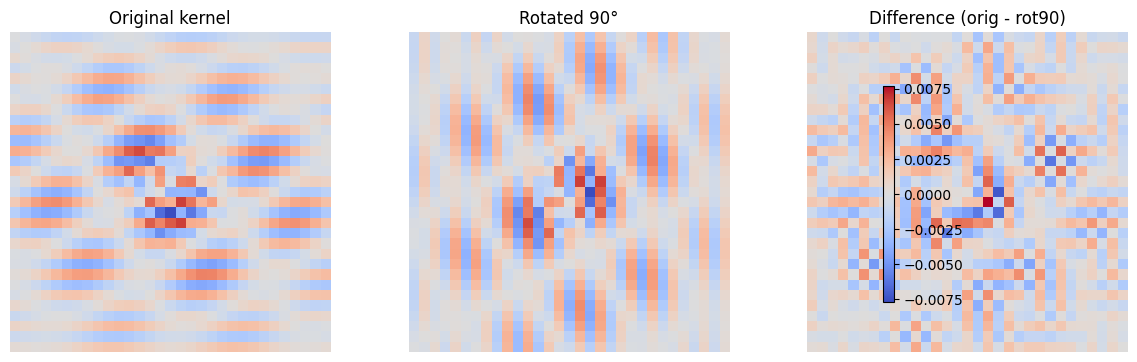

In [3]:
k90 = np.rot90(kernel, 1)
diff90 = kernel - k90

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
vmax = np.max(np.abs(kernel))
axes[0].imshow(kernel, cmap='coolwarm', vmin=-vmax, vmax=vmax)
axes[0].set_title('Original kernel')
axes[1].imshow(k90, cmap='coolwarm', vmin=-vmax, vmax=vmax)
axes[1].set_title('Rotated 90°')
dmax = np.max(np.abs(diff90)) + 1e-12
im = axes[2].imshow(diff90, cmap='coolwarm', vmin=-dmax, vmax=dmax)
axes[2].set_title('Difference (orig - rot90)')
for ax in axes:
    ax.axis('off')
plt.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.tight_layout()
plt.show()


## Test-set evaluation on 90° rotated patches

This section evaluates the saved **regular classifier checkpoint** on the `test` split after rotating every patch by 90 degrees.

In [5]:
from pathlib import Path
import json
import numpy as np

from sklearn.metrics import accuracy_score, roc_auc_score

from kernel_model.data import load_patches_from_folders
from kernel_model.responses import compute_responses
from kernel_model.selection import build_feature_matrix
from kernel_model.models import SimpleLogistic, SimpleMLP

import torch

EXP_DIR = Path('results/exp_022_mmr_nperFamily500_nComposition1250')
KERNELS_PATH = EXP_DIR / 'kernels.npy'
CKPT_PATH = EXP_DIR / 'checkpoint.pt'
CFG_PATH = EXP_DIR / 'config.json'
RES_PATH = EXP_DIR / 'results.json'

for p in [KERNELS_PATH, CKPT_PATH, CFG_PATH, RES_PATH]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required artifact: {p}')

with open(CFG_PATH, 'r') as f:
    cfg = json.load(f)
with open(RES_PATH, 'r') as f:
    res = json.load(f)

data_root = Path(cfg.get('data_root', 'data/patches'))
resize_ps = int(cfg.get('resize_patch_size', 128))
max_per_class = cfg.get('max_per_class', None)
resp_fn = cfg.get('selection', {}).get('response_fn', 'abs_max')
std_patches = bool(cfg.get('selection', {}).get('standardize_responses', False))
batch_size = int(cfg.get('training', {}).get('batch_size', 64))

Xin_test, Xout_test, p_in, p_out = load_patches_from_folders(
    data_root,
    max_per_class=max_per_class,
    resize=(resize_ps, resize_ps),
    return_patient_ids=True,
    splits=('test',),
)
print(f'Loaded test split: Xin={Xin_test.shape}, Xout={Xout_test.shape}')

# Rotate each patch by 90 degrees counter-clockwise
Xin_rot = np.rot90(Xin_test, k=1, axes=(1, 2)).copy()
Xout_rot = np.rot90(Xout_test, k=1, axes=(1, 2)).copy()

# PyTorch >=2.6 defaults to weights_only=True; this checkpoint stores numpy arrays too.
# Use weights_only=False for trusted local artifacts, with compatibility fallback.
try:
    ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
except TypeError:
    ckpt = torch.load(CKPT_PATH, map_location='cpu')
kernels = np.load(KERNELS_PATH).astype(np.float32)
selected_idxs = ckpt.get('selected_idxs')
if selected_idxs is None:
    selected_idxs = res.get('selected_idxs', [])
selected_idxs = list(selected_idxs)
bank_selected = [{'kernel': kernels[i]} for i in selected_idxs]

responses_rot = compute_responses(
    bank_selected,
    Xin_rot,
    Xout_rot,
    device='cpu',
    batch_size=batch_size,
    response_fn=resp_fn,
    standardize_patches=std_patches,
)

X_rot, y_rot, _ = build_feature_matrix(selected_idxs=range(len(bank_selected)), responses=responses_rot, patient_ids_in=p_in, patient_ids_out=p_out)

mean = ckpt.get('mean')
std = ckpt.get('std')
standardize = bool(ckpt.get('standardize', True))
if standardize and mean is not None and std is not None:
    X_eval = (X_rot - mean) / std
else:
    X_eval = X_rot

model_type = ckpt.get('model_type', 'logistic')
in_features = int(ckpt.get('in_features', X_eval.shape[1]))
hidden_dims = tuple(ckpt.get('hidden_dims', [64, 32]))
dropout = float(ckpt.get('dropout', 0.2))
if model_type == 'mlp':
    model = SimpleMLP(in_features, hidden_dims=hidden_dims, dropout=dropout)
else:
    model = SimpleLogistic(in_features)
model.load_state_dict(ckpt['model_state'])
model.eval()

with torch.no_grad():
    probs = torch.sigmoid(model(torch.from_numpy(X_eval).float())).numpy()
pred = (probs > 0.5).astype(np.int32)
acc_rot = accuracy_score(y_rot, pred)
auc_rot = roc_auc_score(y_rot, probs) if len(np.unique(y_rot)) > 1 else float('nan')

orig_test = res.get('eval_results', {}).get('test', {})
print('Original (non-rotated) test metrics from results.json:')
print(f"  AUC={orig_test.get('auc', float('nan')):.6f} ACC={orig_test.get('acc', float('nan')):.6f}")
print('Rotated-90 test metrics (this run):')
print(f"  AUC={auc_rot:.6f} ACC={acc_rot:.6f}")
print('Delta (rotated - original):')
if orig_test:
    print(f"  dAUC={auc_rot - float(orig_test.get('auc', 0.0)):+.6f} dACC={acc_rot - float(orig_test.get('acc', 0.0)):+.6f}")


Loaded test split: Xin=(1040, 128, 128), Xout=(830, 128, 128)


Kernels: 100%|██████████| 90/90 [04:18<00:00,  2.87s/it]

Original (non-rotated) test metrics from results.json:
  AUC=0.933321 ACC=0.873262
Rotated-90 test metrics (this run):
  AUC=0.934988 ACC=0.885561
Delta (rotated - original):
  dAUC=+0.001667 dACC=+0.012299


## Extension: run the same experiment with a rotation-invariant composed kernel

This section loads the saved composed kernel, builds a **rotation-invariant kernel** by averaging
its 0°/90°/180°/270° rotations, retrains a single-feature classifier on train,
then evaluates on original test and 90°-rotated test patches.

Train split: Xin=(2800, 128, 128), Xout=(3000, 128, 128)
Test split : Xin=(1040, 128, 128), Xout=(830, 128, 128)
Built rotation-invariant kernel by averaging rotations at: 0, 90, 180, 270 degrees


/tmp/ipykernel_37220/1251353325.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


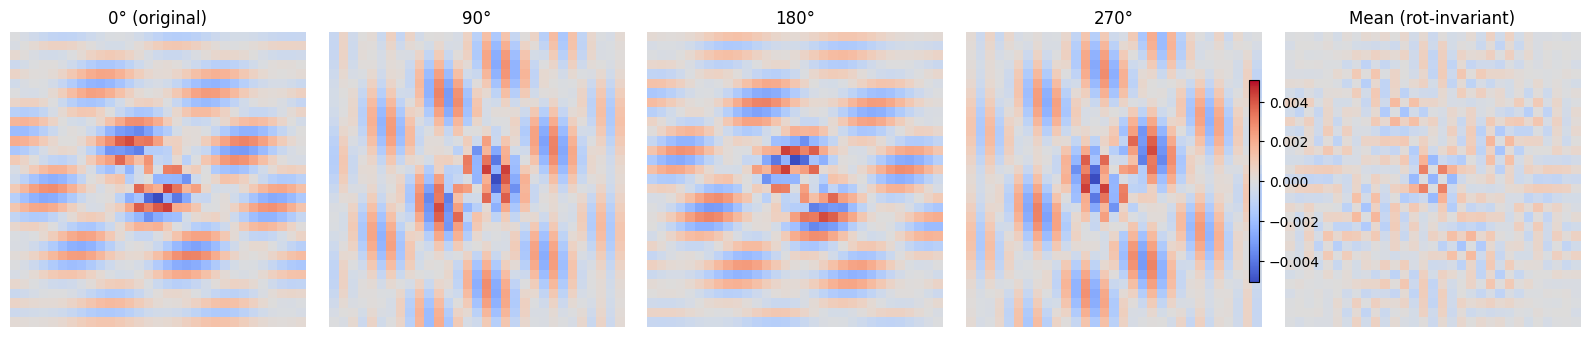

Kernels: 100%|██████████| 1/1 [00:02<00:00,  2.78s/it]

Saved composite test metrics from previous run:
  AUC=0.893287 ACC=0.814973
Rotation-invariant composed kernel (retrained) - original test metrics:
  AUC=0.890774 ACC=0.809626
Rotation-invariant composed kernel (retrained) - rotated-90 test metrics:
  AUC=0.890774 ACC=0.809626
Delta (rotated - original):
  dAUC=+0.000000 dACC=+0.000000


In [2]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import accuracy_score, roc_auc_score

from kernel_model.data import load_patches_from_folders
from kernel_model.responses import compute_responses
from kernel_model.models import train_classifier
from kernel_model.selection import build_feature_matrix

EXP_DIR = Path('results/exp_022_mmr_nperFamily500_nComposition1250')
CFG_PATH = EXP_DIR / 'config.json'
RES_PATH = EXP_DIR / 'results.json'
COMPOSITE_KERNEL_PATH = EXP_DIR / 'composite_kernel.npy'

for p in [CFG_PATH, RES_PATH, COMPOSITE_KERNEL_PATH]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required artifact: {p}')

cfg = json.loads(CFG_PATH.read_text())
res = json.loads(RES_PATH.read_text())

data_root = Path(cfg.get('data_root', 'data/patches'))
resize_ps = int(cfg.get('resize_patch_size', 128))
max_per_class = cfg.get('max_per_class', None)
batch_size = int(cfg.get('training', {}).get('batch_size', 64))
resp_fn = cfg.get('selection', {}).get('response_fn', 'abs_max')
std_patches = bool(cfg.get('selection', {}).get('standardize_responses', False))

Xin_train, Xout_train, p_in_train, p_out_train = load_patches_from_folders(
    data_root,
    max_per_class=max_per_class,
    resize=(resize_ps, resize_ps),
    return_patient_ids=True,
    splits=('train',),
)

Xin_test, Xout_test, p_in_test, p_out_test = load_patches_from_folders(
    data_root,
    max_per_class=max_per_class,
    resize=(resize_ps, resize_ps),
    return_patient_ids=True,
    splits=('test',),
)

print(f'Train split: Xin={Xin_train.shape}, Xout={Xout_train.shape}')
print(f'Test split : Xin={Xin_test.shape}, Xout={Xout_test.shape}')

composite_kernel = np.load(COMPOSITE_KERNEL_PATH).astype(np.float32)
rotated_kernels = [np.rot90(composite_kernel, k=k).copy() for k in range(4)]
rotation_invariant_kernel = np.mean(np.stack(rotated_kernels, axis=0), axis=0).astype(np.float32)

print('Built rotation-invariant kernel by averaging rotations at: 0, 90, 180, 270 degrees')

# Visualize original, rotated, and averaged kernels
kernels_to_show = rotated_kernels + [rotation_invariant_kernel]
titles = ['0° (original)', '90°', '180°', '270°', 'Mean (rot-invariant)']
visual_v = max(float(np.max(np.abs(k))) for k in kernels_to_show) + 1e-12
fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
for ax, k, title in zip(axes, kernels_to_show, titles):
    im = ax.imshow(k, cmap='coolwarm', vmin=-visual_v, vmax=visual_v)
    ax.set_title(title)
    ax.axis('off')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75)
plt.tight_layout()
plt.show()

composite_bank = [
    {
        'family': 'composite',
        'params': {'rotation_invariant': True, 'angles_deg': [0, 90, 180, 270], 'aggregation': 'mean'},
        'kernel': rotation_invariant_kernel,
    }
]

responses_train = compute_responses(
    composite_bank,
    Xin_train,
    Xout_train,
    device='cpu',
    batch_size=batch_size,
    response_fn=resp_fn,
    standardize_patches=std_patches,
)

training_cfg = cfg.get('training', {})
composite_clf = train_classifier(
    Xin_train,
    Xout_train,
    [0],
    responses_train,
    epochs=int(training_cfg.get('epochs', 60)),
    batch_size=batch_size,
    lr=float(training_cfg.get('lr', 5e-4)),
    device='cpu',
    model_type=training_cfg.get('model_type', 'logistic'),
    hidden_dims=tuple(training_cfg.get('hidden_dims', [64, 32])),
    dropout=float(training_cfg.get('dropout', 0.2)),
    standardize=bool(training_cfg.get('standardize_features', True)),
    subset_frac=training_cfg.get('train_subset_frac', None),
    subset_size=training_cfg.get('train_subset_size', None),
    subset_seed=int(training_cfg.get('subset_seed', 42)),
    patient_ids_in=p_in_train,
    patient_ids_out=p_out_train,
)

def eval_composite_split(Xin, Xout, p_in, p_out):
    responses = compute_responses(
        composite_bank,
        Xin,
        Xout,
        device='cpu',
        batch_size=batch_size,
        response_fn=resp_fn,
        standardize_patches=std_patches,
    )
    X_feat, y_true, _ = build_feature_matrix([0], responses, patient_ids_in=p_in, patient_ids_out=p_out)

    X_eval = X_feat
    if composite_clf.get('standardize') and composite_clf.get('mean') is not None and composite_clf.get('std') is not None:
        X_eval = (X_eval - composite_clf['mean']) / composite_clf['std']

    model = composite_clf['model']
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(torch.from_numpy(X_eval).float())).cpu().numpy()

    acc = accuracy_score(y_true, (probs > 0.5).astype(int))
    auc = roc_auc_score(y_true, probs) if len(np.unique(y_true)) > 1 else float('nan')
    return {'auc': float(auc), 'acc': float(acc), 'n': int(len(y_true))}

angles_deg = [0, 90, 180, 270]
test_results_by_angle = {}
for ang in angles_deg:
    if ang == 0:
        Xin_eval, Xout_eval = Xin_test, Xout_test
    else:
        k = ang // 90
        Xin_eval = np.rot90(Xin_test, k=k, axes=(1, 2)).copy()
        Xout_eval = np.rot90(Xout_test, k=k, axes=(1, 2)).copy()
    test_results_by_angle[ang] = eval_composite_split(Xin_eval, Xout_eval, p_in_test, p_out_test)

saved = res.get('composite', {}).get('eval_results', {}).get('test', {})
print('\nSaved composite test metrics from results.json:')
if saved:
    print(f"  AUC={saved.get('auc', float('nan')):.6f} ACC={saved.get('acc', float('nan')):.6f}")
else:
    print('  (none)')

print('\nRotation-invariant kernel results (this run):')
for ang in angles_deg:
    tag = 'original' if ang == 0 else f'rot{ang}'
    m = test_results_by_angle[ang]
    print(f"  Test {tag:<8} | AUC={m['auc']:.6f} ACC={m['acc']:.6f} N={m['n']}")

base = test_results_by_angle[0]
print('\nDeltas vs original:')
for ang in [90, 180, 270]:
    m = test_results_by_angle[ang]
    print(f"  rot{ang:<3} | dAUC={m['auc'] - base['auc']:+.6f} dACC={m['acc'] - base['acc']:+.6f}")

results_rotinv = {
    'test_by_angle': test_results_by_angle,
    'test_original': test_results_by_angle[0],
    'test_rot90': test_results_by_angle[90],
    'test_rot180': test_results_by_angle[180],
    'test_rot270': test_results_by_angle[270],
}

